# WiDS Dataset – Exploratory Data Analysis (EDA)

Focus:
- Feature distributions
- Missing (null) values



## 1. Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

real_path = 'Real_Datasets/WiDS_cleaned.csv'
df = pd.read_csv(real_path)

print('Dataset shape:', df.shape)
df.head()

Dataset shape: (85389, 48)


,elective_surgery,ethnicity,gender,height,icu_admit_source,icu_stay_type,icu_type,pre_icu_los_days,readmission_status,apache_2_diagnosis,...,cirrhosis,diabetes_mellitus,hepatic_failure,immunosuppression,leukemia,lymphoma,solid_tumor_with_metastasis,apache_3j_bodysystem,apache_2_bodysystem,hospital_death
0,0,Caucasian,M,180.3,Floor,admit,CTICU,0.541667,0,113.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,Sepsis,Cardiovascular,0
1,0,Caucasian,F,160.0,Floor,admit,Med-Surg ICU,0.927778,0,108.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,Respiratory,Respiratory,0
2,0,Caucasian,F,172.7,Accident & Emergency,admit,Med-Surg ICU,0.000694,0,122.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Metabolic,Metabolic,0
3,1,Caucasian,F,165.1,Operating Room / Recovery,admit,CTICU,0.000694,0,203.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Cardiovascular,Cardiovascular,0
4,0,Caucasian,M,190.5,Accident & Emergency,admit,Med-Surg ICU,0.000694,0,301.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,Neurological,Neurologic,0


## 2. Data Types

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85389 entries, 0 to 85388
Data columns (total 48 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   elective_surgery             85389 non-null  int64  
 1   ethnicity                    85389 non-null  object 
 2   gender                       85389 non-null  object 
 3   height                       85389 non-null  float64
 4   icu_admit_source             85389 non-null  object 
 5   icu_stay_type                85389 non-null  object 
 6   icu_type                     85389 non-null  object 
 7   pre_icu_los_days             85389 non-null  float64
 8   readmission_status           85389 non-null  int64  
 9   apache_2_diagnosis           85389 non-null  float64
 10  apache_3j_diagnosis          85389 non-null  float64
 11  apache_post_operative        85389 non-null  int64  
 12  arf_apache                   85389 non-null  float64
 13  gcs_unable_apach

In [3]:
df["apache_2_diagnosis"] = df["apache_2_diagnosis"].astype(str)
df["apache_3j_diagnosis"] = df["apache_3j_diagnosis"].astype(str)

## 3. Missing Values

In [4]:
missing_abs = df.isna().sum().sort_values(ascending=False)
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)

missing_df = pd.DataFrame({
    'missing_count': missing_abs,
    'missing_percent': missing_pct
})

total_cells = df.shape[0] * df.shape[1]
total_missing = df.isna().sum().sum()

missing_percentage = (total_missing / total_cells) * 100
print("total missing values:", missing_percentage)

missing_df[missing_df.missing_count > 0].head(20)

total missing values: 0.0


,missing_count,missing_percent


## 4. Missing Values Plot

In [5]:
if missing_pct[missing_pct > 0].size == 0:
    print("no missing values to plot")
else:
    print(missing_pct[missing_pct > 0].size)
    plt.figure(figsize=(10,5))
    missing_pct[missing_pct > 0].plot(kind='bar')
    plt.ylabel('Missing (%)')
    plt.title('Missing Values per Column')
    plt.tight_layout()
    plt.show()

no missing values to plot


In [6]:
x = 2  # threshold in percent

missing_pct = df.isna().mean() * 100
df_filtered = df.loc[:, missing_pct <= x]
#df_filtered = df_filtered.drop('icu_id', axis=1)

removed = set(df.columns) - set(df_filtered.columns)
print("Dropped columns:", removed)

df_filtered2 = df_filtered[df_filtered.isna().sum(axis=1) < 1]
print("Original shape:", df.shape)
print("Filtered shape:", df_filtered.shape)

print("Rows removed:", df.shape[0] - df_filtered2.shape[0])



print("Filtered2 shape:", df_filtered2.shape)

target = "hospital_death"  # change if needed

cols = [c for c in df_filtered2.columns if c != target] + [target]
df_filtered3 = df_filtered2[cols]

print("Filtered3 shape:", df_filtered3.shape)


#df_filtered3.to_csv('Real_Datasets/WiDS_cleaned.csv',index=False)

Dropped columns: set()
Original shape: (85389, 48)
Filtered shape: (85389, 48)
Rows removed: 0
Filtered2 shape: (85389, 48)
Filtered3 shape: (85389, 48)


In [7]:
print(f"\n{'='*60}")
print(f"NaN overview:")
print(f"{'='*60}")

total_rows = len(df)

# Replace inf with NaN so we catch those too
df = df.replace([np.inf, -np.inf], np.nan)

# Column-wise NaN count
nan_counts = df.isna().sum()
nan_percent = (nan_counts / total_rows * 100).round(2)

summary = pd.DataFrame({
    "NaN Count": nan_counts,
    "NaN %": nan_percent
}).sort_values("NaN Count", ascending=False)

print("\nColumn-wise NaN summary:")
display(summary[summary["NaN Count"] > 0])

# Row-level info
rows_with_nan = df.isna().any(axis=1).sum()
print(f"\nTotal rows: {total_rows}")
print(f"Rows containing at least one NaN: {rows_with_nan}")
print(f"Percentage of rows with NaN: {(rows_with_nan/total_rows*100):.2f}%")

# Show example problematic rows
if rows_with_nan > 0:
    print("\nExample rows with NaNs:")
    display(df[df.isna().any(axis=1)].head())

print(summary)




NaN overview:

Column-wise NaN summary:


,NaN Count,NaN %



Total rows: 85389
Rows containing at least one NaN: 0
Percentage of rows with NaN: 0.00%
                             NaN Count  NaN %
elective_surgery                     0    0.0
ethnicity                            0    0.0
d1_mbp_min                           0    0.0
d1_mbp_noninvasive_max               0    0.0
d1_mbp_noninvasive_min               0    0.0
d1_resprate_max                      0    0.0
d1_resprate_min                      0    0.0
d1_spo2_max                          0    0.0
d1_spo2_min                          0    0.0
d1_sysbp_max                         0    0.0
d1_sysbp_min                         0    0.0
d1_sysbp_noninvasive_max             0    0.0
d1_sysbp_noninvasive_min             0    0.0
aids                                 0    0.0
cirrhosis                            0    0.0
diabetes_mellitus                    0    0.0
hepatic_failure                      0    0.0
immunosuppression                    0    0.0
leukemia                            

## 5. Numeric Distributions

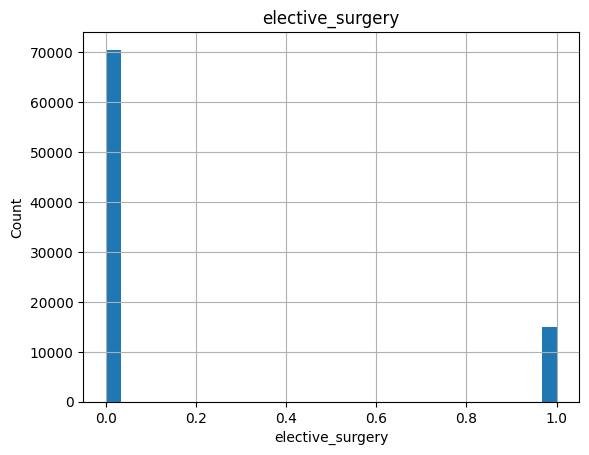

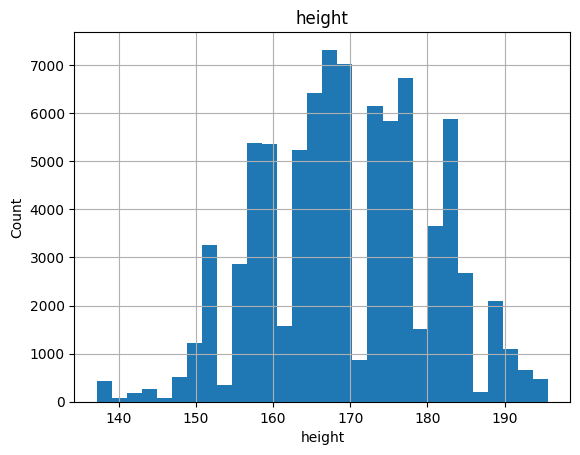

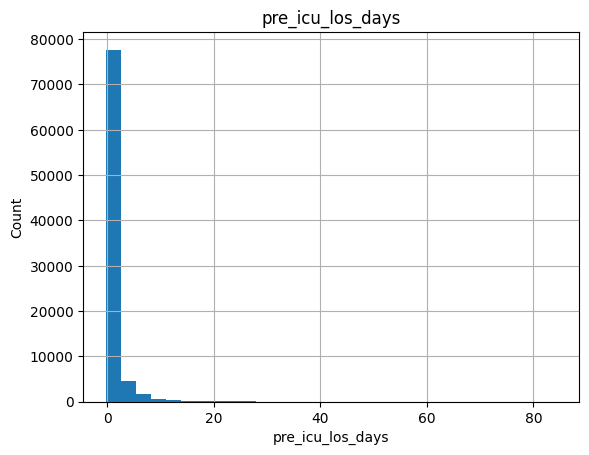

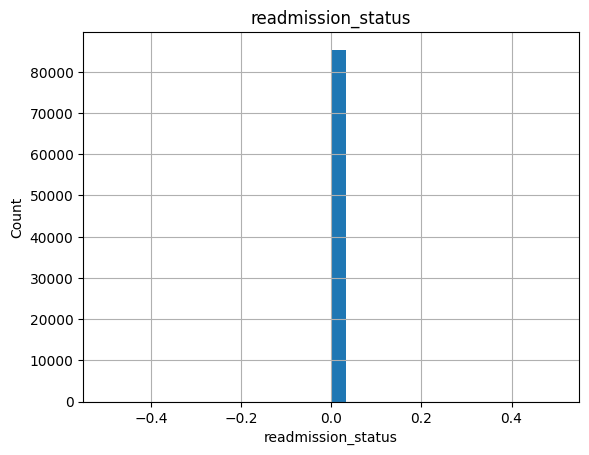

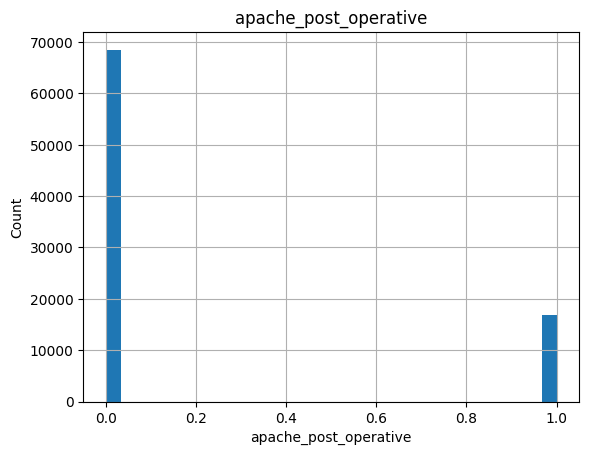

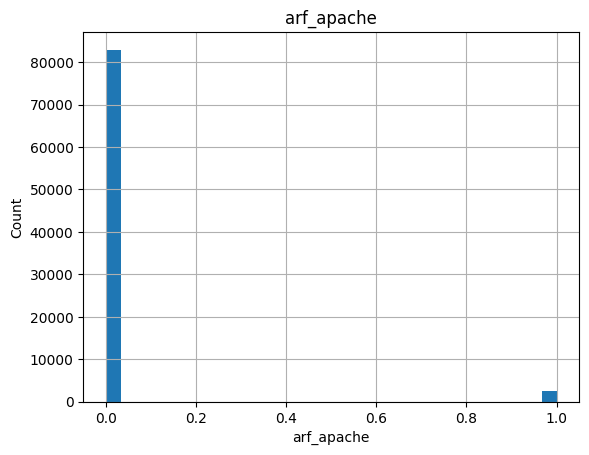

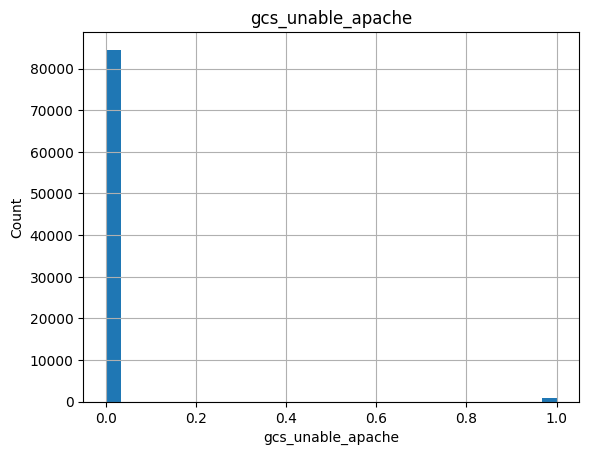

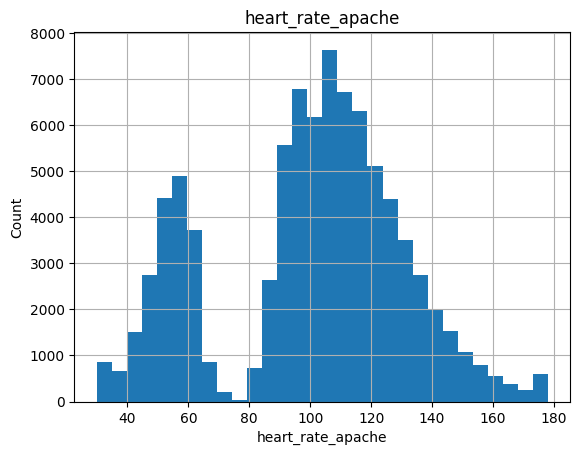

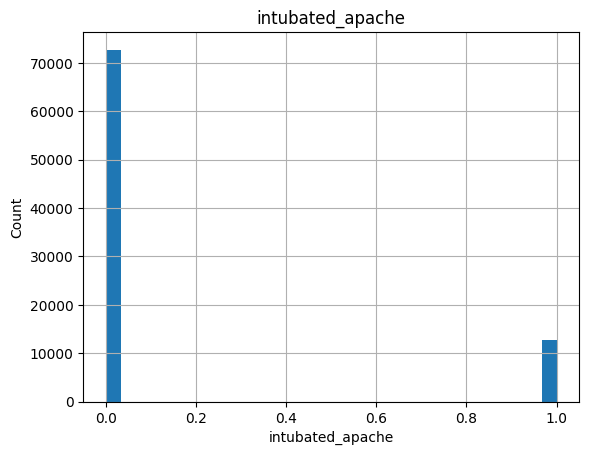

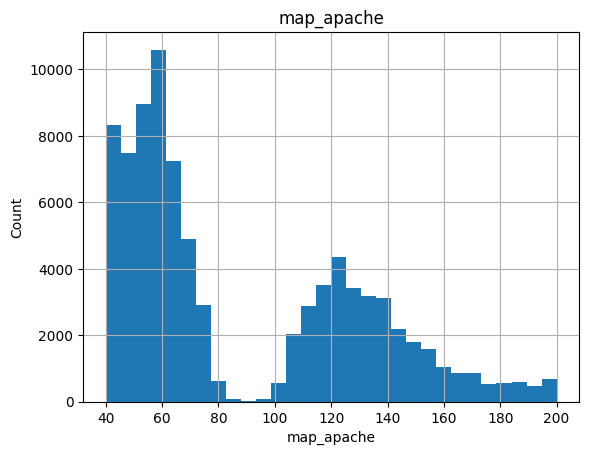

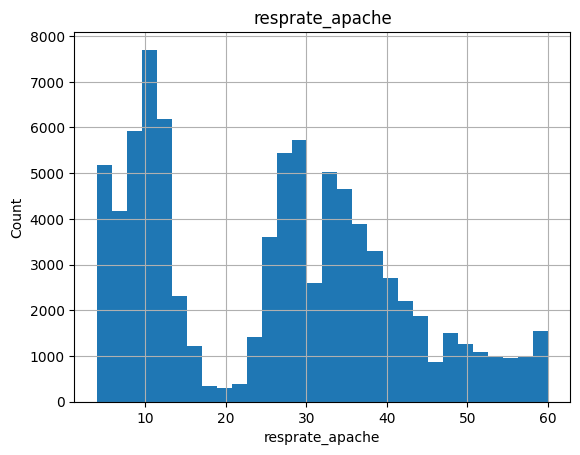

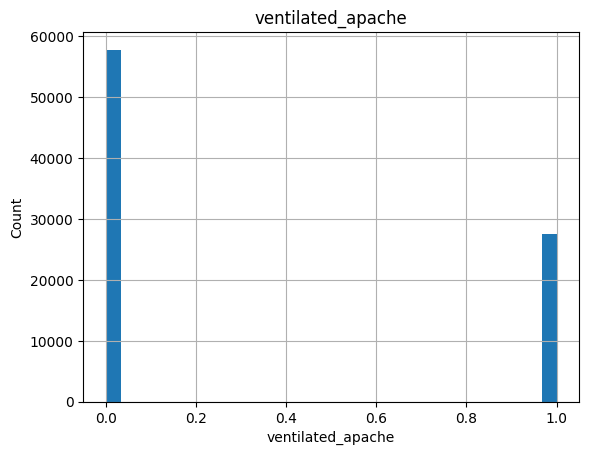

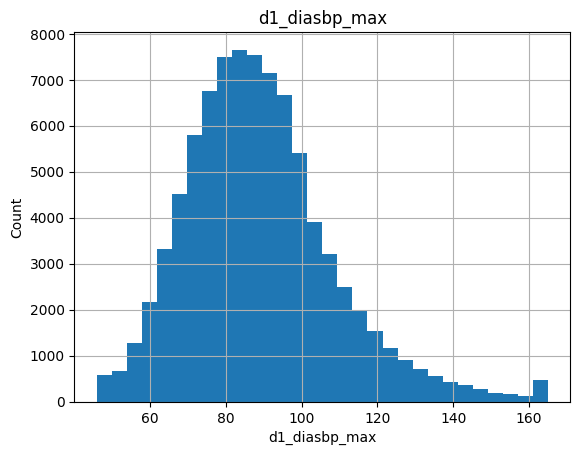

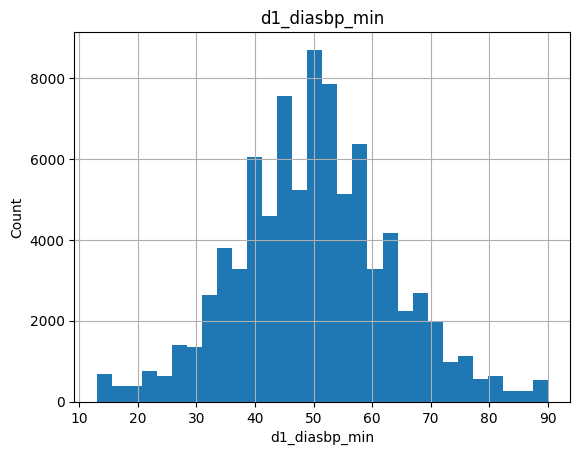

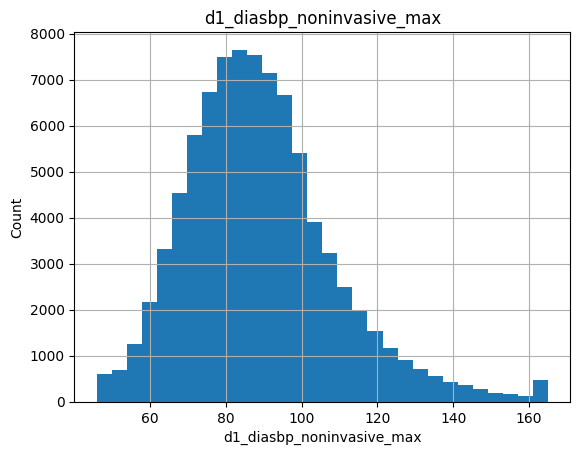

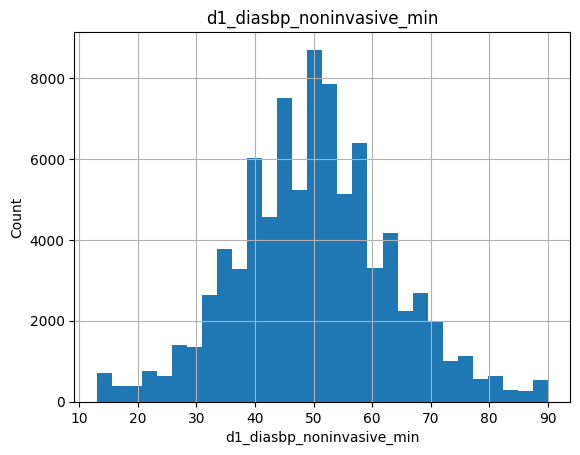

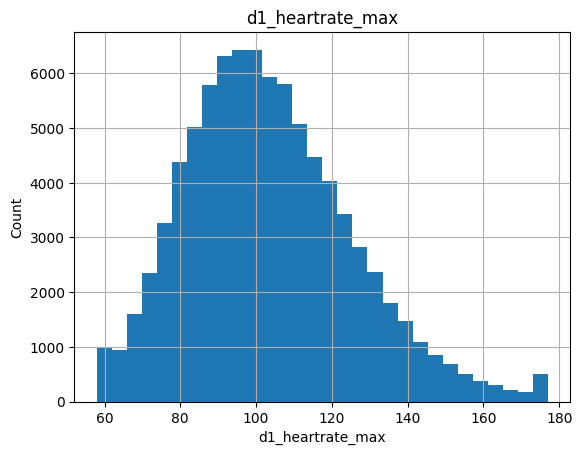

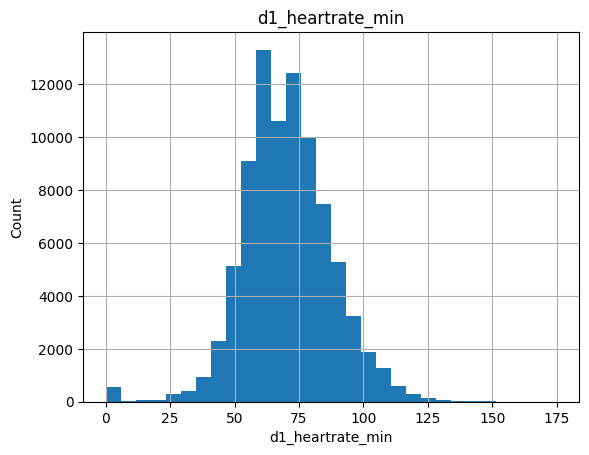

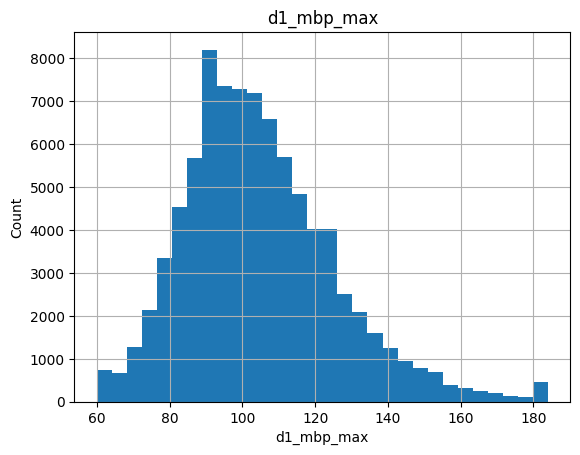

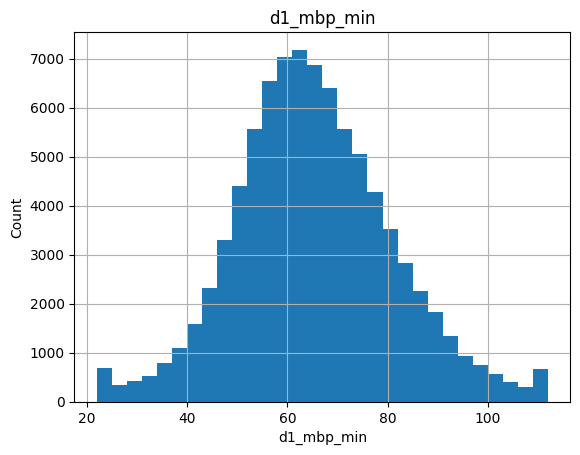

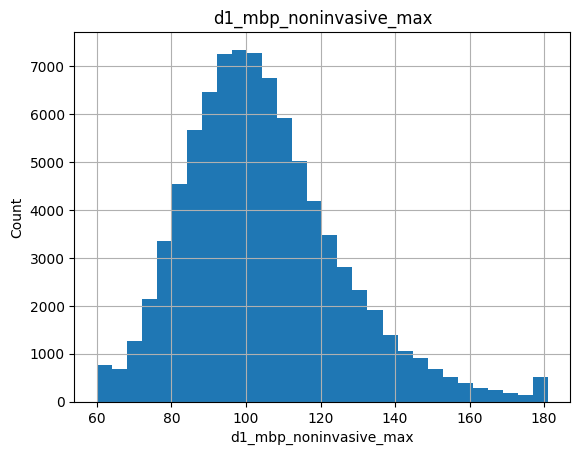

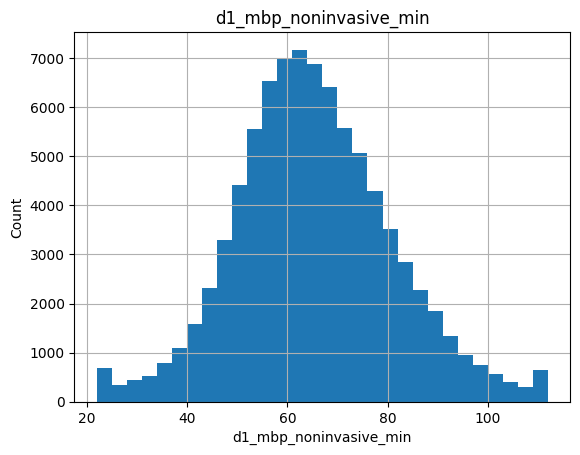

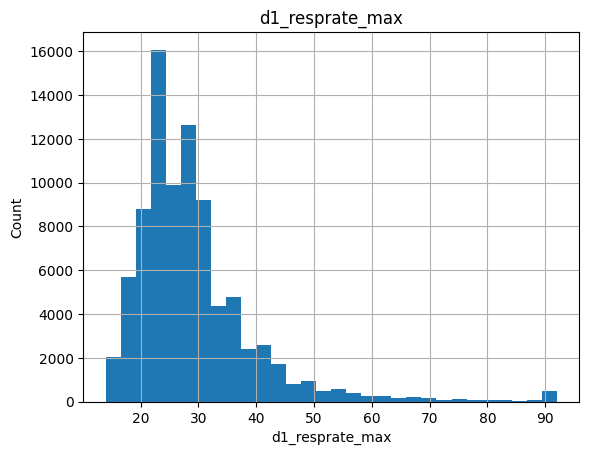

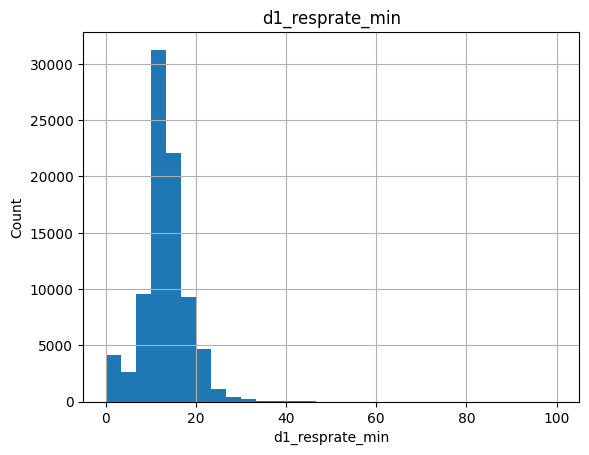

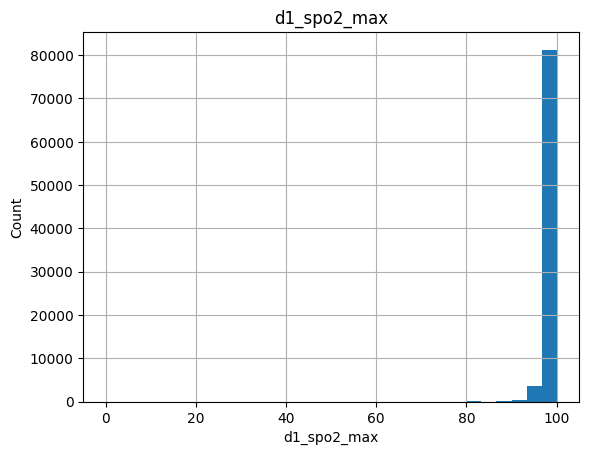

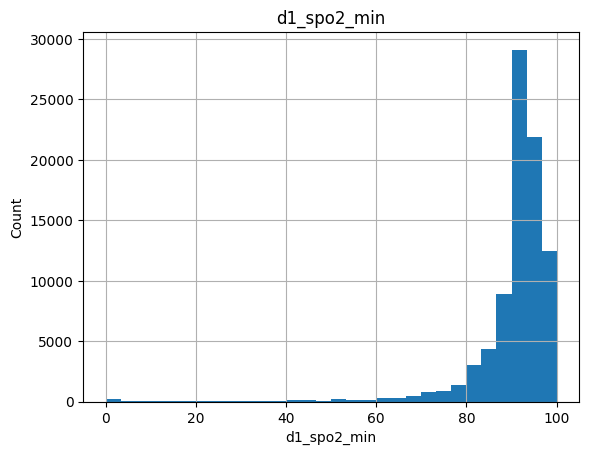

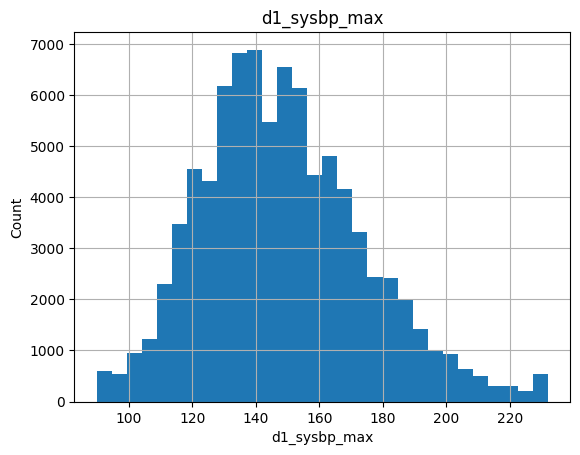

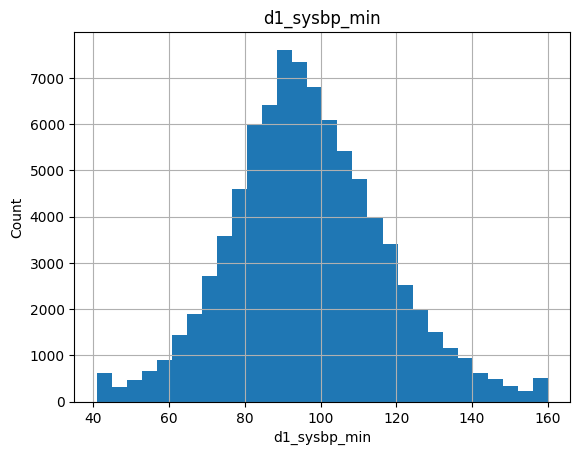

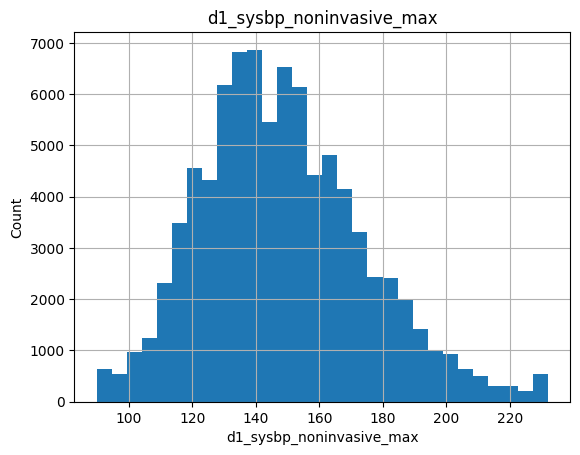

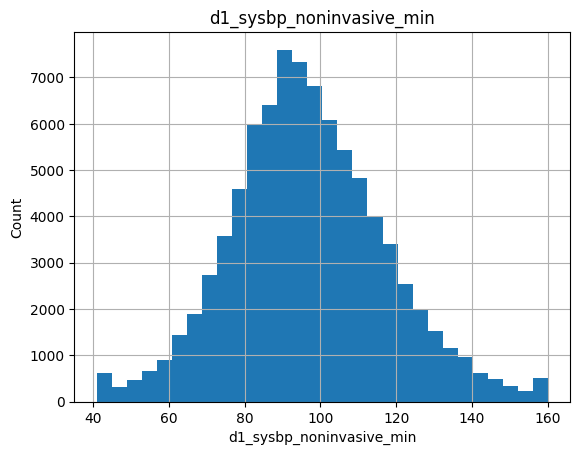

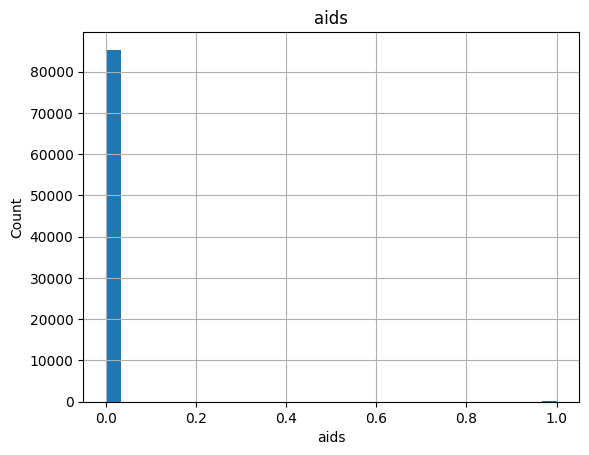

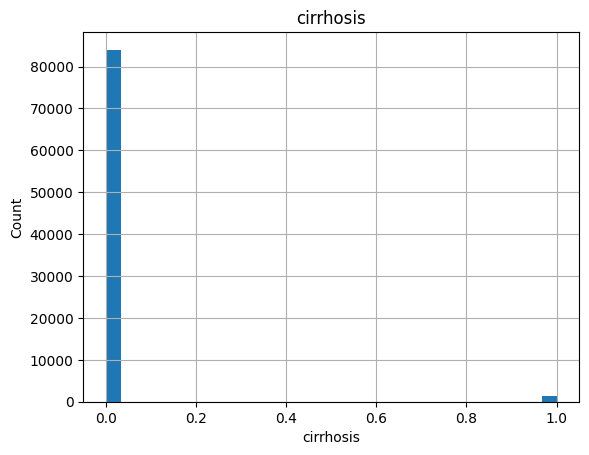

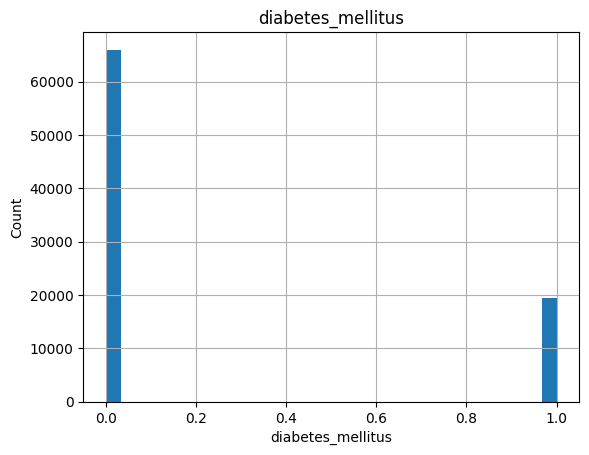

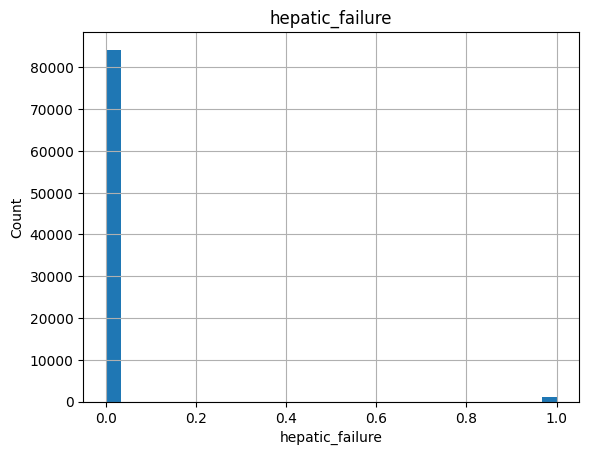

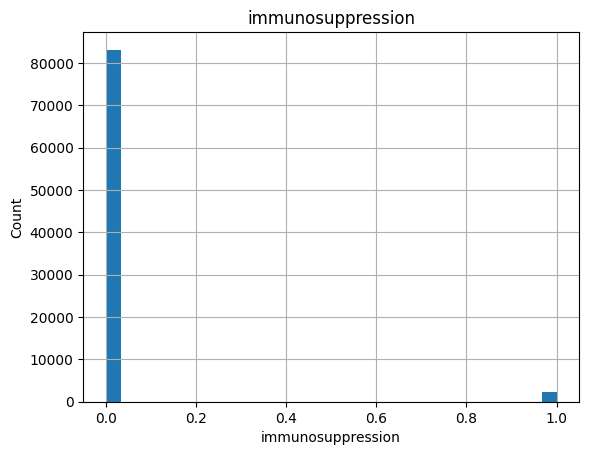

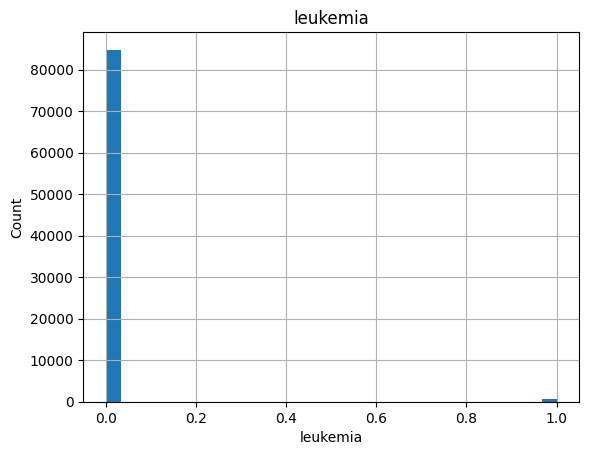

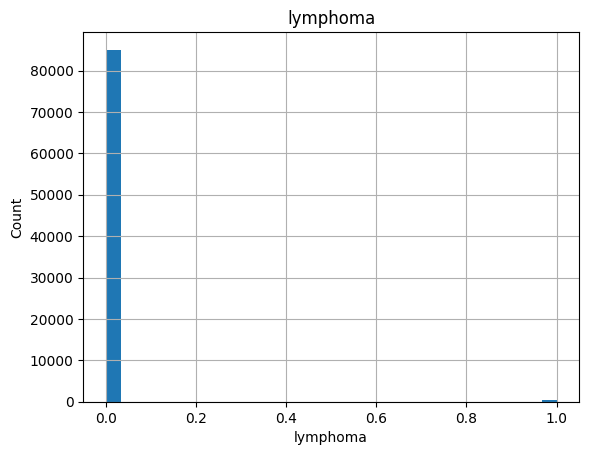

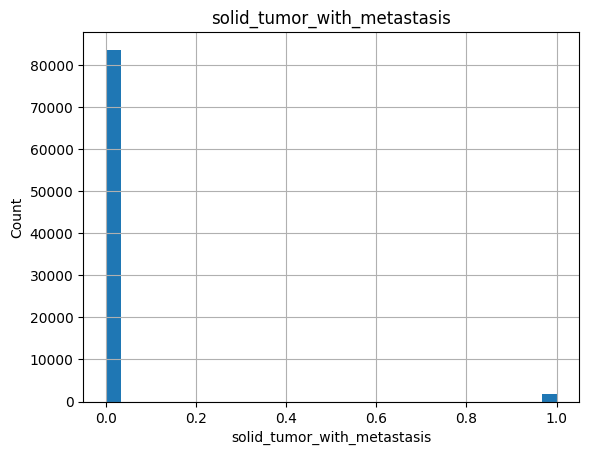

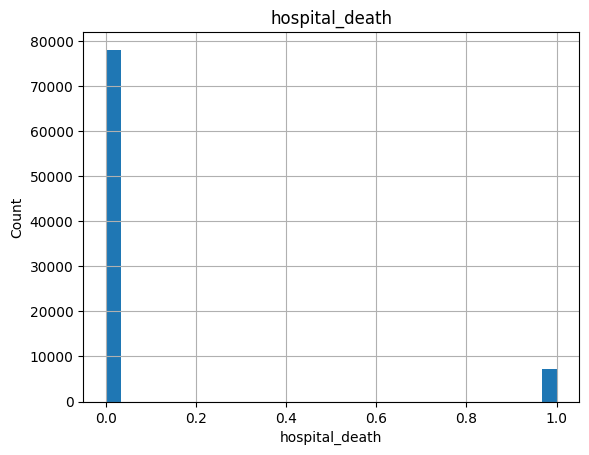

In [8]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
for col in num_cols:
    plt.figure()
    df[col].dropna().hist(bins=30)
    plt.title(col)
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.show()

## 6. Categorical Distributions

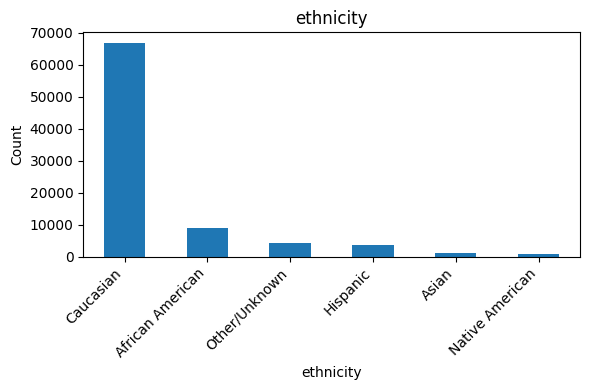

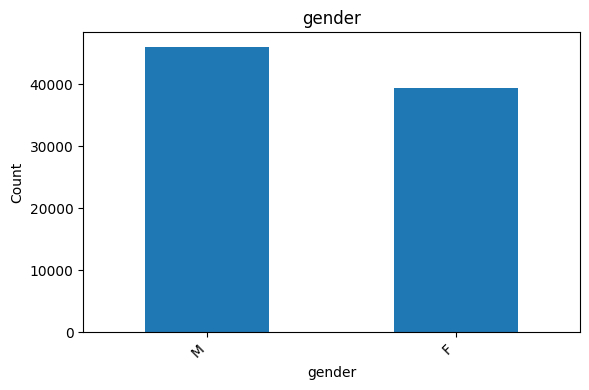

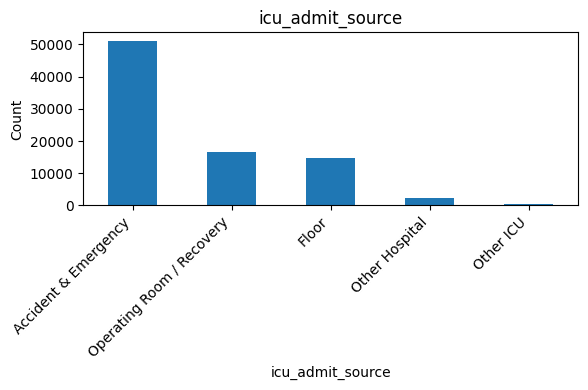

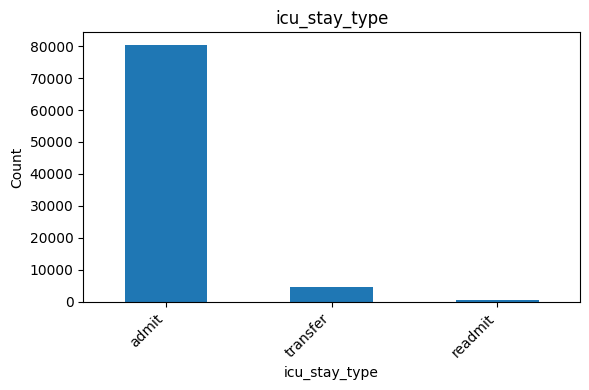

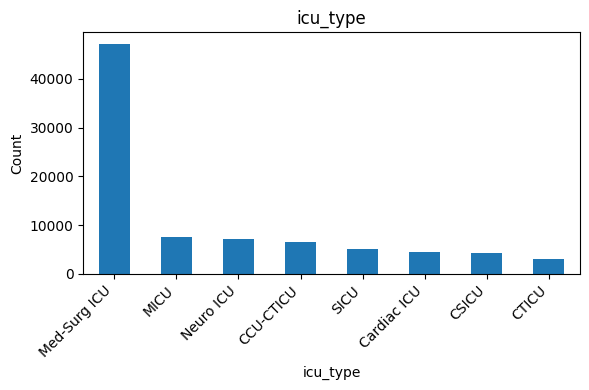

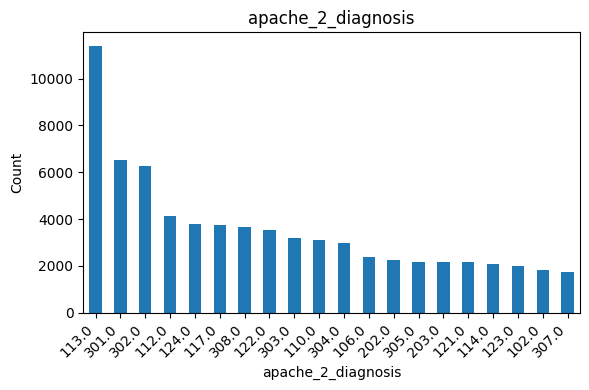

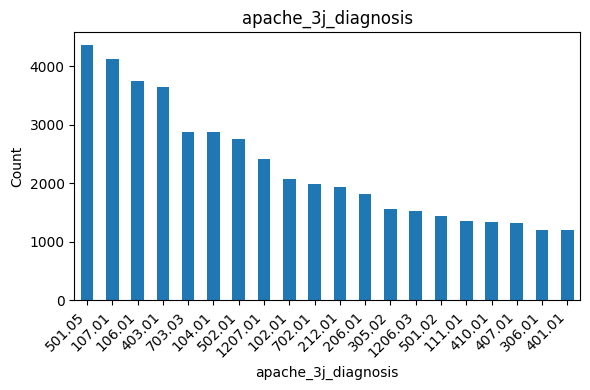

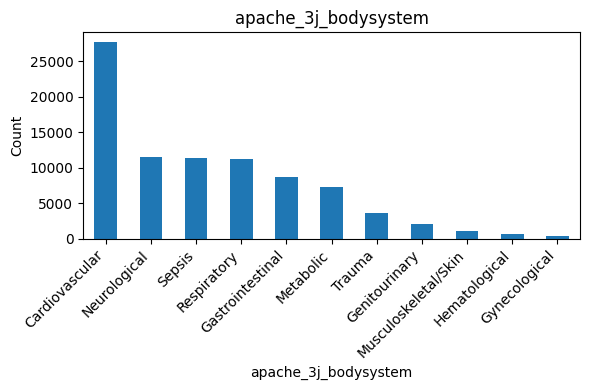

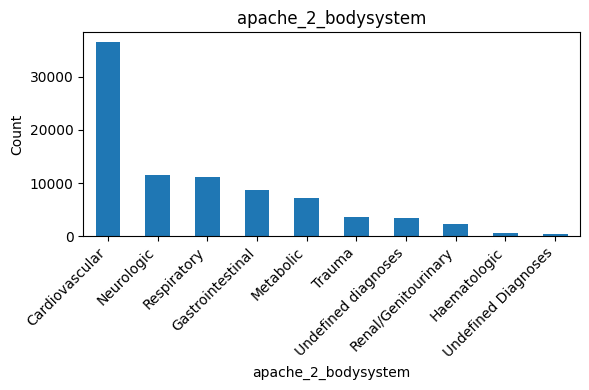

In [9]:
cat_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()
for col in cat_cols:
    plt.figure(figsize=(6,4))
    df[col].value_counts(dropna=False).head(20).plot(kind='bar')
    plt.title(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

## 7. Notes
- Columns with high missingness may need imputation or removal
- Highly skewed distributions may require transformation before GAN training